# Diabetes Risk Data Exploration (Introduction)

In this project we are working with a diabetes dataset to understand what affects a person’s risk of getting diabetes. The goal is to explore the data, see patterns, and understand the different features before moving to modelling.

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
#sns.set(style="whitegrid") sets a clean background style for the graphs making them easier to read. 

# Loading the Dataset

In this step, we will load the dataset so we can start exploring it. This allows us to see what the data looks like and understand the different columns.

In [3]:
df = pd.read_csv("../data/Diabetes_and_LifeStyle_Dataset_.csv")
df.head(10)

,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,...,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,...,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,...,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,37,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,...,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,...,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


# Observation

The dataset contains 31 columns which include both lifestyle and medical information.

# Data Inspection

Here we will check the structure of the dataset, including the number of rows, column types, and summary statistics.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97297 entries, 0 to 97296
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 97297 non-null  int64  
 1   gender                              97297 non-null  str    
 2   ethnicity                           97297 non-null  str    
 3   education_level                     97297 non-null  str    
 4   income_level                        97297 non-null  str    
 5   employment_status                   97297 non-null  str    
 6   smoking_status                      97297 non-null  str    
 7   alcohol_consumption_per_week        97297 non-null  int64  
 8   physical_activity_minutes_per_week  97297 non-null  int64  
 9   diet_score                          97297 non-null  float64
 10  sleep_hours_per_day                 97297 non-null  float64
 11  screen_time_hours_per_day           97297 non-null  

# Understanding the Dataset Structure (df.info())

In this step, we use df.info() to understand the structure of the dataset.

This helps us see:
- the number of rows and columns
- the data types of each column (e.g. integer, float, string)
- whether there are any missing values
This is important because it helps us understand the quality of the data before doing further analysis.

# Observation (df.info())

The dataset has 97,297 rows and 31 columns. All columns have the same number of values, which means there are no missing values.

The dataset includes a mix of data types:
- numerical data (e.g. age, BMI, glucose levels)
- categorical data (e.g. gender, smoking status)

This shows that the dataset is complete and ready for analysis.

In [5]:
df.describe()

#This cell code helps us understand:
#- the average (mean) values
#- how spread out the data is (standard deviation)
#- the minimum and maximum values
#- the distribution of the data (quartiles)

,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [6]:
pd.set_option('display.max_columns', None)
#It tells pandas to show all the columns and not hide anything

# Observation (df.describe())

From the summary statistics, we can see that the average age is around 50 years, which means most patients are middle-aged. The average BMI is around 25.6, which is close to the overweight range and may increase diabetes risk. Glucose levels are also slightly high on average (fasting ≈ 111), which suggests that many patients may already be at risk. Some variables such as physical activity have a very wide range (0 to over 800 minutes) which indicates possible outliers or extreme values.

# Diabetes Stage Distribution

In this step, we used a countplot to show how many patients fall into each diabetes stage.
A countplot is used to count how many times each category appears in a dataset.
This helps us understand how the data is distributed and whether some categories have more data than others.

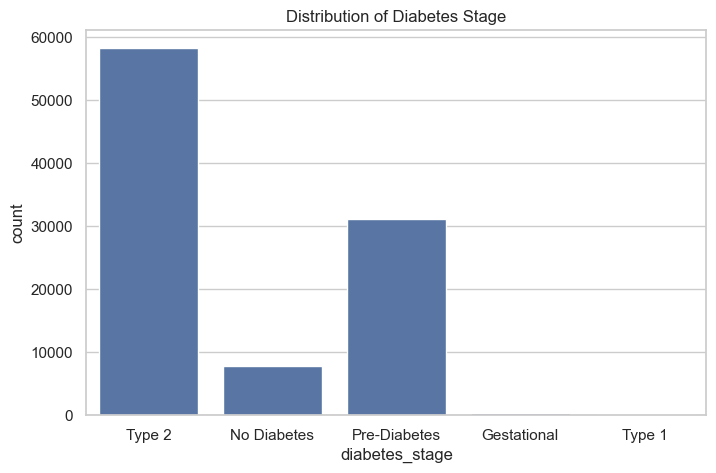

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(x='diabetes_stage', data=df)
plt.title('Distribution of Diabetes Stage')
plt.show()

# Observation (Count Plot)

Most patients fall under the Type 2 diabetes category which is much higher than the other stages.
Pre-diabetes is the second largest group, while fewer patients are in the no diabetes category.
Type 1 and gestational diabetes are present but are very small compared to the other groups which makes them difficult to see clearly on the graph.
Therefore, the dataset is highly imbalanced which may affect how well the model predicts the smaller classes.

# Feature Distributions (Histograms)

In this step, we use histograms to understand how different numerical features are distributed. A histogram shows how values are spread across a range, which helps us identify patterns such as normal distribution, skewness, and extreme values.

We selected specific numerical features that are directly related to lifestyle and general health, such as age, BMI, physical activity, sleep, screen time, and diet score. These features were chosen because they are known to influence overall health and may contribute to diabetes risk. Categorical variables such as gender and smoking status were not included in this step, as histograms are better suited for numerical data. This allows us to focus on meaningful patterns in the data without overcrowding the analysis.

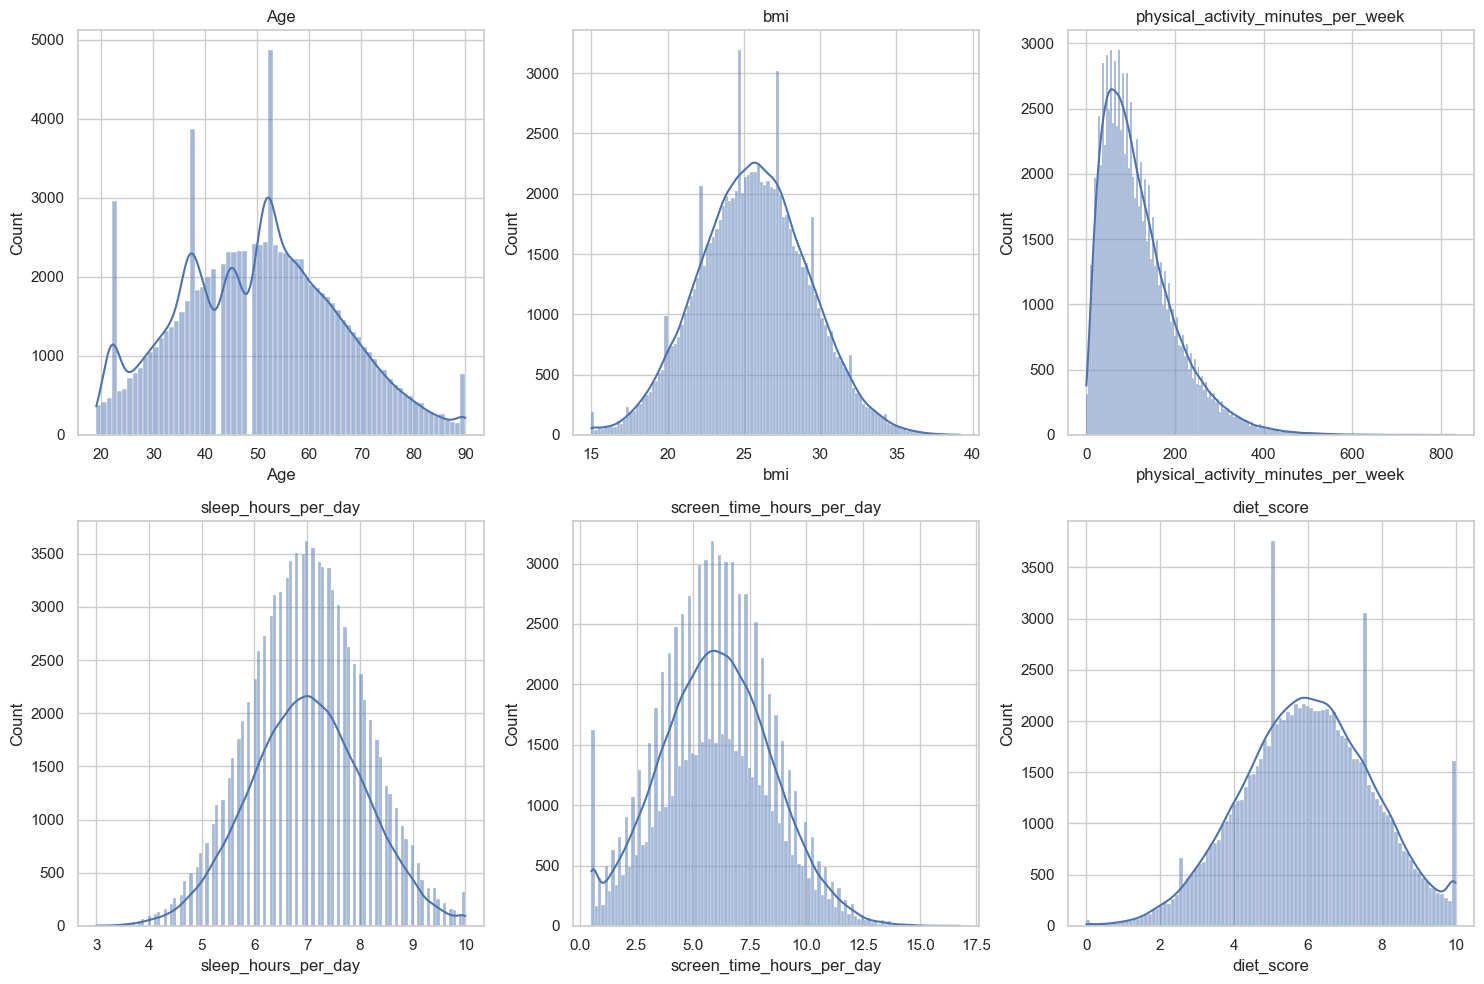

In [8]:
columns1 = ['Age', 'bmi', 'physical_activity_minutes_per_week',
        'sleep_hours_per_day', 'screen_time_hours_per_day', 'diet_score']

plt.figure(figsize=(15,10))

for i, col in enumerate(columns1, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Observation

Age shows a slightly uneven distribution with most patients falling in the middle-age range.
BMI appears close to normally distributed with most values around the middle range indicating many patients are within a similar weight range.
Physical activity is highly skewed to the right meaning most patients have low to moderate activity levels while only a few have very high values.
Sleep hours follow a fairly normal distribution with most patients getting around 6 to 8 hours of sleep.
Screen time also shows a roughly normal distribution although it has a wider spread compared to sleep.
Diet score is centred around the middle values which suggests that most patients have an average diet rather than very poor or very healthy diets.
Overall, the distributions show a mix of normal and skewed patterns, especially in lifestyle features such as physical activity which may be important when analysing diabetes risk.

# Medical Feature Distributions

In this step, we analysed the distribution of key medical features related to diabetes.
These include glucose levels, cholesterol, triglycerides, insulin, and HbA1c. These variables are directly linked to a patient’s health condition and are important indicators of diabetes risk.

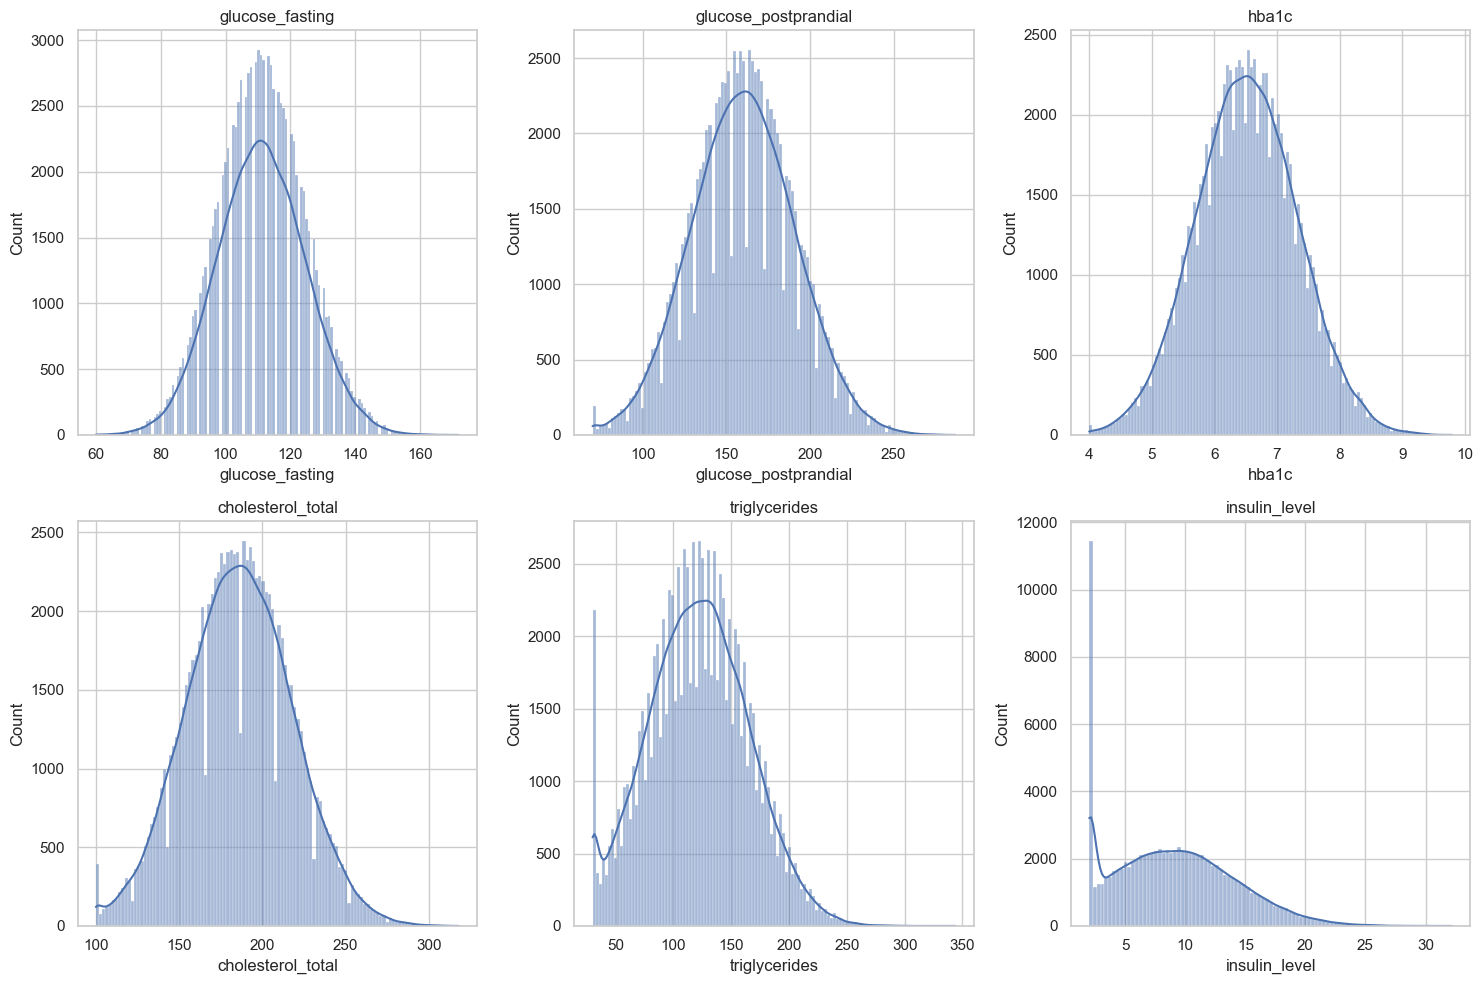

In [9]:
columns2 = ['glucose_fasting', 'glucose_postprandial', 'hba1c',
         'cholesterol_total', 'triglycerides', 'insulin_level']

plt.figure(figsize=(15,10))

for i, col in enumerate(columns2, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Observation

Glucose levels (fasting and postprandial) show a fairly normal distribution although some values extend to higher ranges.
HbA1c also shows a normal distribution with most values around the middle.
Cholesterol and triglycerides have a moderate distribution with some higher values that may indicate risk.
Insulin levels are highly skewed to the right with most patients having low values and a few having very high values.

# Outlier Analysis (Boxplots)

In this step, we used boxplots to identify outliers in the dataset.
A boxplot shows the distribution of the data and highlights values that fall far outside the normal range.
This helps us detect extreme values that may affect the analysis and modelling.

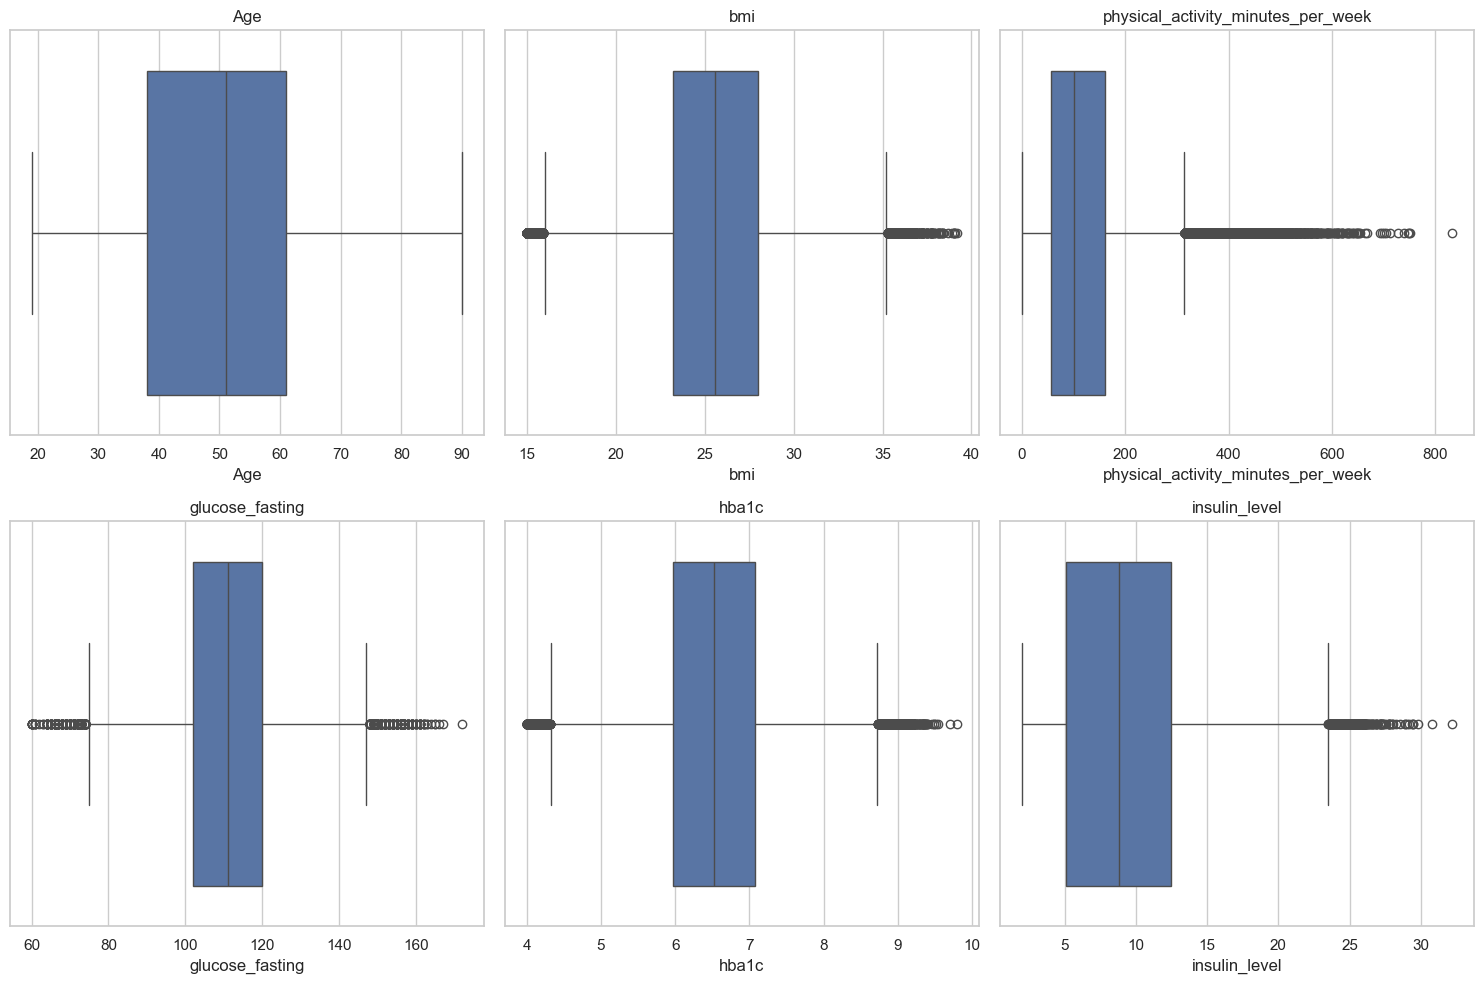

In [11]:
columns1 = ['Age', 'bmi', 'physical_activity_minutes_per_week',
        'glucose_fasting', 'hba1c', 'insulin_level']

plt.figure(figsize=(15,10))

for i, col in enumerate(columns1, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Observation

Physical activity has many extreme values on the high end, indicating strong right skewness.
Glucose and HbA1c also show elevated values, which may be linked to an increased risk of diabetes.
Insulin levels are highly skewed, with several high-value outliers.
Age and BMI appear more stable, with fewer extreme values compared to the other features.

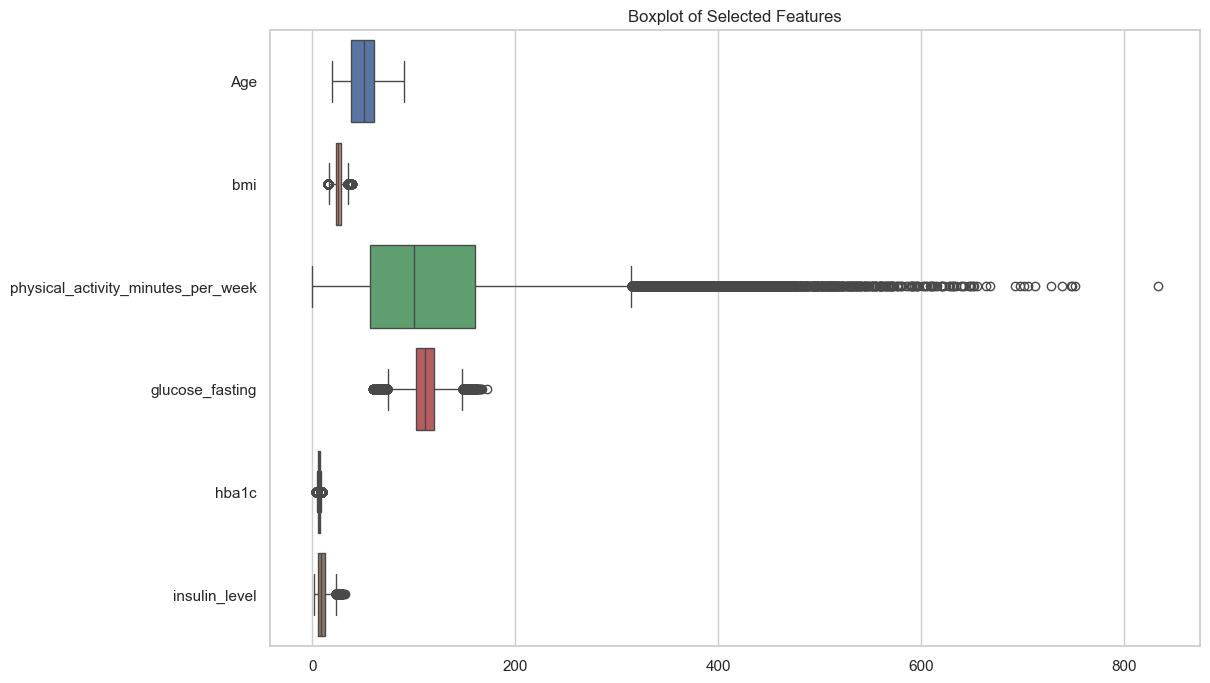

In [12]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df[['Age', 'bmi', 'physical_activity_minutes_per_week',
                     'glucose_fasting', 'hba1c', 'insulin_level']],
            orient='h')

plt.title('Boxplot of Selected Features')
plt.show()

# Correlation Analysis (Heatmap)

In this step, we used a heatmap to analyse the relationships between numerical features.
A heatmap shows the correlation between variables, where values closer to 1 or -1 indicate stronger relationships, and values close to 0 indicate weak or no relationship.
This helps us understand how different features are related to each other, especially those linked to diabetes risk.

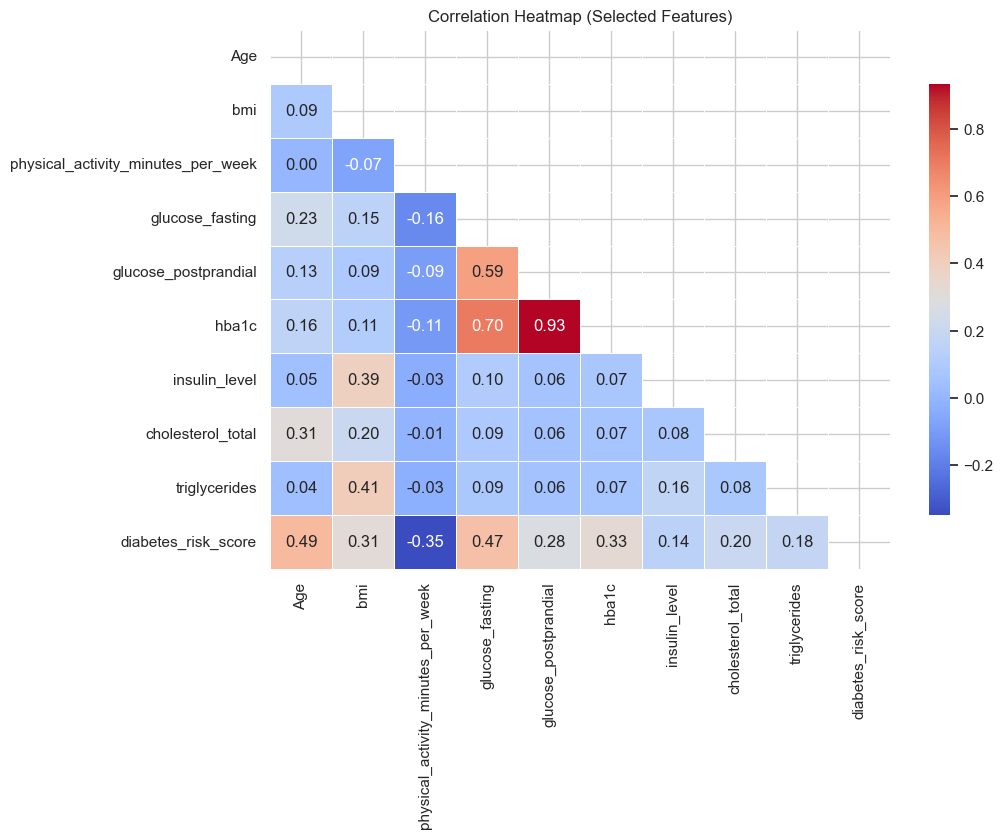

In [14]:
cols = ['Age', 'bmi', 'physical_activity_minutes_per_week',
        'glucose_fasting', 'glucose_postprandial',
        'hba1c', 'insulin_level',
        'cholesterol_total', 'triglycerides',
        'diabetes_risk_score']

corr = df[cols].corr()

# Mask
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10,7))

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap (Selected Features)")
plt.show()

# Correlation Analysis (Heatmap)

In this step, we use a heatmap to analyse the relationships between selected numerical features.
We focused on key variables related to general health and diabetes, such as age, BMI, physical activity, glucose levels, HbA1c, insulin, cholesterol, triglycerides, and diabetes risk score. 
These features were selected because they are directly linked to a patient’s health condition and are important indicators of diabetes risk.
Using all numerical variables would make the heatmap difficult to interpret, so a subset of relevant features was chosen to ensure the analysis remains clear and meaningful.

# Observation

The heatmap shows that glucose_postprandial and HbA1c have a strong positive correlation, indicating a close relationship between these measures.
Glucose_fasting also shows moderate positive correlations with both glucose_postprandial and HbA1c.
Diabetes risk score has moderate positive relationships with age, glucose levels, and BMI, suggesting these factors may contribute to higher risk.
Cholesterol and triglycerides show weaker correlations with most variables.
Physical activity shows weak or slightly negative relationships with some features, indicating limited linear association.
Overall, medical features related to glucose and HbA1c show stronger relationships, while lifestyle features tend to have weaker correlations.



## Summary of Key Findings

In this analysis, we explored the dataset to understand the distribution, patterns, and relationships between features related to diabetes.

The distribution of the target variable shows that the dataset is not balanced, with most patients falling under Type 2 diabetes, while categories like Type 1 and gestational diabetes have much fewer cases.

From the histograms, some features such as BMI and sleep hours follow a roughly normal distribution, while others like physical activity and insulin levels are skewed. This shows that the data is not evenly distributed across all features.

The boxplots show that there are outliers in several variables, especially in physical activity, glucose levels, and insulin. These extreme values may affect the analysis and should be considered later when preparing the data.

The heatmap shows that medical features such as glucose levels and HbA1c are more strongly related to each other, while lifestyle features have weaker relationships. The diabetes risk score also shows moderate relationships with features like age, BMI, and glucose levels.

Overall, the analysis shows that both medical and lifestyle factors are important, but the stronger relationships are mainly between the medical features.

## Data Dictionary

- Age: Age of the patient  
- gender: Gender of the patient  
- ethnicity: Ethnic background of the patient  
- education_level: Highest level of education  
- income_level: Income category of the patient  
- employment_status: Employment status  
- smoking_status: Smoking behaviour (e.g. never, former, current)  
- alcohol_consumption_per_week: Number of alcoholic drinks per week  
- physical_activity_minutes_per_week: Weekly physical activity in minutes  
- diet_score: Score representing diet quality  
- sleep_hours_per_day: Average hours of sleep per day  
- screen_time_hours_per_day: Daily screen time in hours  
- family_history_diabetes: Whether the patient has a family history of diabetes  
- hypertension_history: History of high blood pressure  
- cardiovascular_history: History of heart-related conditions  
- bmi: Body Mass Index  
- waist_to_hip_ratio: Ratio of waist size to hip size  
- systolic_bp: Systolic blood pressure  
- diastolic_bp: Diastolic blood pressure  
- heart_rate: Heart rate  
- cholesterol_total: Total cholesterol level  
- hdl_cholesterol: High-density lipoprotein (good cholesterol)  
- ldl_cholesterol: Low-density lipoprotein (bad cholesterol)  
- triglycerides: Triglyceride levels  
- glucose_fasting: Fasting blood glucose level  
- glucose_postprandial: Blood glucose after eating  
- insulin_level: Insulin level  
- hba1c: Average blood sugar level over time  
- diabetes_risk_score: Calculated risk score for diabetes  
- diabetes_stage: Category of diabetes (e.g. No Diabetes, Pre-Diabetes, Type 1, Type 2)  
- diagnosed_diabetes: Whether the patient is diagnosed with diabetes (0 or 1)  